In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# Database connection
DB_URL = f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
engine = create_engine(DB_URL)

# Load clean data
df = pd.read_sql("SELECT * FROM clean_fruits ORDER BY fruit_id", engine)

print(f"Loaded {len(df)} fruits")

# Define features (X) and target (y)
features = ['sugar', 'carbohydrates', 'protein', 'fat']
target = 'calories'

X = df[features].copy()
y = df[target].copy()

# Check for missing values
print(f"\nMissing values in features: {X.isnull().sum().sum()}")
print(f"Missing values in target: {y.isnull().sum()}")

# Drop rows with missing target
valid_indices = ~y.isnull()
X = X[valid_indices]
y = y[valid_indices]

print(f"\nFinal dataset: {len(X)} fruits with complete data")

Loaded 49 fruits

Missing values in features: 0
Missing values in target: 0

Final dataset: 49 fruits with complete data


In [14]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=" * 50)
print("DATA SPLIT")
print("=" * 50)
print(f"Training set: {len(X_train)} fruits")
print(f"Test set: {len(X_test)} fruits")
print(f"\nTraining features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"\nTarget mean (train): {y_train.mean():.2f}")
print(f"Target mean (test): {y_test.mean():.2f}")

DATA SPLIT
Training set: 39 fruits
Test set: 10 fruits

Training features shape: (39, 4)
Test features shape: (10, 4)

Target mean (train): 70.69
Target mean (test): 60.00


In [15]:
# Initialize and train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# Evaluate
train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
train_rmse_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
train_r2_lr = r2_score(y_train, y_train_pred_lr)

test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)
test_rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
test_r2_lr = r2_score(y_test, y_test_pred_lr)

print("=" * 50)
print("LINEAR REGRESSION PERFORMANCE")
print("=" * 50)
print("Training Set:")
print(f"  MAE:  {train_mae_lr:.2f}")
print(f"  RMSE: {train_rmse_lr:.2f}")
print(f"  R²:   {train_r2_lr:.3f}")
print("\nTest Set:")
print(f"  MAE:  {test_mae_lr:.2f}")
print(f"  RMSE: {test_rmse_lr:.2f}")
print(f"  R²:   {test_r2_lr:.3f}")

# Feature coefficients
print("\nFeature Coefficients (importance):")
for feature, coef in zip(features, lr_model.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"  Intercept: {lr_model.intercept_:.2f}")

LINEAR REGRESSION PERFORMANCE
Training Set:
  MAE:  5.10
  RMSE: 9.14
  R²:   0.990

Test Set:
  MAE:  8.81
  RMSE: 11.54
  R²:   0.915

Feature Coefficients (importance):
  sugar: 0.94
  carbohydrates: 2.42
  protein: 1.06
  fat: 9.07
  Intercept: 11.52


In [16]:
# Initialize and train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,      # Number of trees
    max_depth=6,           # Maximum depth of each tree
    random_state=42
)
rf_model.fit(X_train, y_train)

# Make predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Evaluate
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
train_r2_rf = r2_score(y_train, y_train_pred_rf)

test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print("=" * 50)
print("RANDOM FOREST PERFORMANCE")
print("=" * 50)
print("Training Set:")
print(f"  MAE:  {train_mae_rf:.2f}")
print(f"  RMSE: {train_rmse_rf:.2f}")
print(f"  R²:   {train_r2_rf:.3f}")
print("\nTest Set:")
print(f"  MAE:  {test_mae_rf:.2f}")
print(f"  RMSE: {test_rmse_rf:.2f}")
print(f"  R²:   {test_r2_rf:.3f}")

# Feature importance
print("\nFeature Importance:")
importance = rf_model.feature_importances_
for feature, imp in zip(features, importance):
    print(f"  {feature}: {imp:.3f}")

RANDOM FOREST PERFORMANCE
Training Set:
  MAE:  9.78
  RMSE: 27.15
  R²:   0.916

Test Set:
  MAE:  19.81
  RMSE: 27.04
  R²:   0.532

Feature Importance:
  sugar: 0.038
  carbohydrates: 0.166
  protein: 0.325
  fat: 0.471


In [17]:
# Compare models side by side
comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Linear Regression (Train)': [train_mae_lr, train_rmse_lr, train_r2_lr],
    'Linear Regression (Test)': [test_mae_lr, test_rmse_lr, test_r2_lr],
    'Random Forest (Train)': [train_mae_rf, train_rmse_rf, train_r2_rf],
    'Random Forest (Test)': [test_mae_rf, test_rmse_rf, test_r2_rf]
})

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(comparison.to_string(index=False))

# Determine which model is better
test_r2_diff = test_r2_rf - test_r2_lr
if test_r2_diff > 0.05:
    winner = "Random Forest"
    reason = f"higher R² ({test_r2_rf:.3f} vs {test_r2_lr:.3f})"
elif test_r2_diff > 0:
    winner = "Random Forest (slightly)"
    reason = f"marginally higher R² ({test_r2_rf:.3f} vs {test_r2_lr:.3f})"
else:
    winner = "Linear Regression"
    reason = f"higher R² ({test_r2_lr:.3f} vs {test_r2_rf:.3f})"

print(f"\nBetter Model: {winner}")
print(f"   Reason: {reason}")
print(f"   Random Forest improvement over Linear Regression: {test_r2_diff:.3f} R²")

MODEL COMPARISON
Metric  Linear Regression (Train)  Linear Regression (Test)  Random Forest (Train)  Random Forest (Test)
   MAE                   5.104652                  8.805400               9.780576             19.813901
  RMSE                   9.136251                 11.543207              27.149489             27.035160
    R²                   0.990488                  0.914772               0.916000              0.532493

Better Model: Linear Regression
   Reason: higher R² (0.915 vs 0.532)
   Random Forest improvement over Linear Regression: -0.382 R²


OVERFITTING CHECK - Random Forest (different max_depth)
max_depth Train R² Test R²   Gap
        2    0.904   0.314 0.590
        4    0.915   0.520 0.395
        6    0.916   0.532 0.384
        8    0.916   0.520 0.396
       10    0.916   0.539 0.376
     None    0.916   0.540 0.376

Best max_depth: None
   Train R²: 0.916
   Test R²:  0.540
   Gap:      0.376


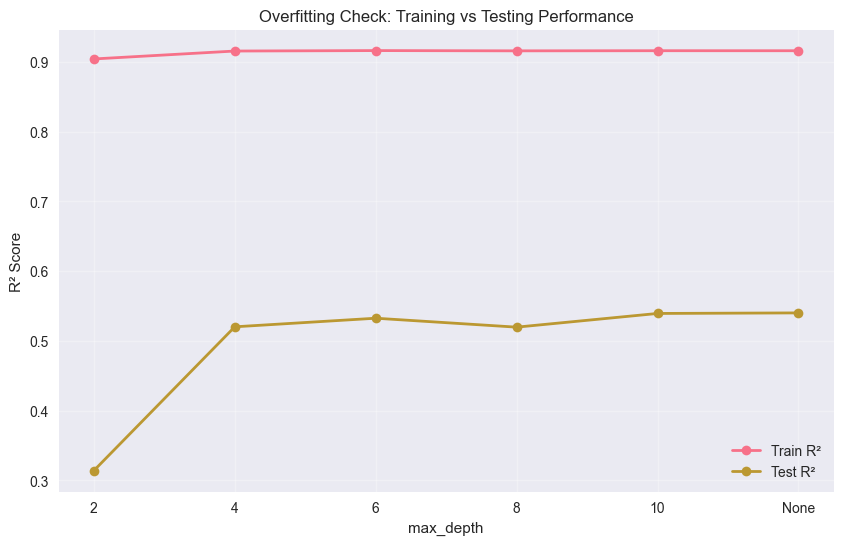

In [18]:
# Test different max_depth values for Random Forest
max_depths = [2, 4, 6, 8, 10, None]
train_scores = []
test_scores = []

for depth in max_depths:
    if depth is None:
        label = "None"
        model = RandomForestRegressor(n_estimators=100, random_state=42)
    else:
        label = str(depth)
        model = RandomForestRegressor(n_estimators=100, max_depth=depth, random_state=42)

    model.fit(X_train, y_train)
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2 = r2_score(y_test, model.predict(X_test))
    train_scores.append(train_r2)
    test_scores.append(test_r2)

# Create overfitting check dataframe
overfit_df = pd.DataFrame({
    'max_depth': [str(d) for d in max_depths],
    'Train R²': [f"{s:.3f}" for s in train_scores],
    'Test R²': [f"{s:.3f}" for s in test_scores],
    'Gap': [f"{train_scores[i] - test_scores[i]:.3f}" for i in range(len(test_scores))]
})

print("=" * 60)
print("OVERFITTING CHECK - Random Forest (different max_depth)")
print("=" * 60)
print(overfit_df.to_string(index=False))

# Find best depth
best_depth_idx = np.argmax(test_scores)
best_depth = max_depths[best_depth_idx]
print(f"\nBest max_depth: {best_depth}")
print(f"   Train R²: {train_scores[best_depth_idx]:.3f}")
print(f"   Test R²:  {test_scores[best_depth_idx]:.3f}")
print(f"   Gap:      {train_scores[best_depth_idx] - test_scores[best_depth_idx]:.3f}")

# Plot overfitting analysis
plt.figure(figsize=(10, 6))
depth_labels = [str(d) if d is not None else "None" for d in max_depths]
plt.plot(depth_labels, train_scores, marker='o', label='Train R²', linewidth=2)
plt.plot(depth_labels, test_scores, marker='o', label='Test R²', linewidth=2)
plt.xlabel('max_depth')
plt.ylabel('R² Score')
plt.title('Overfitting Check: Training vs Testing Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

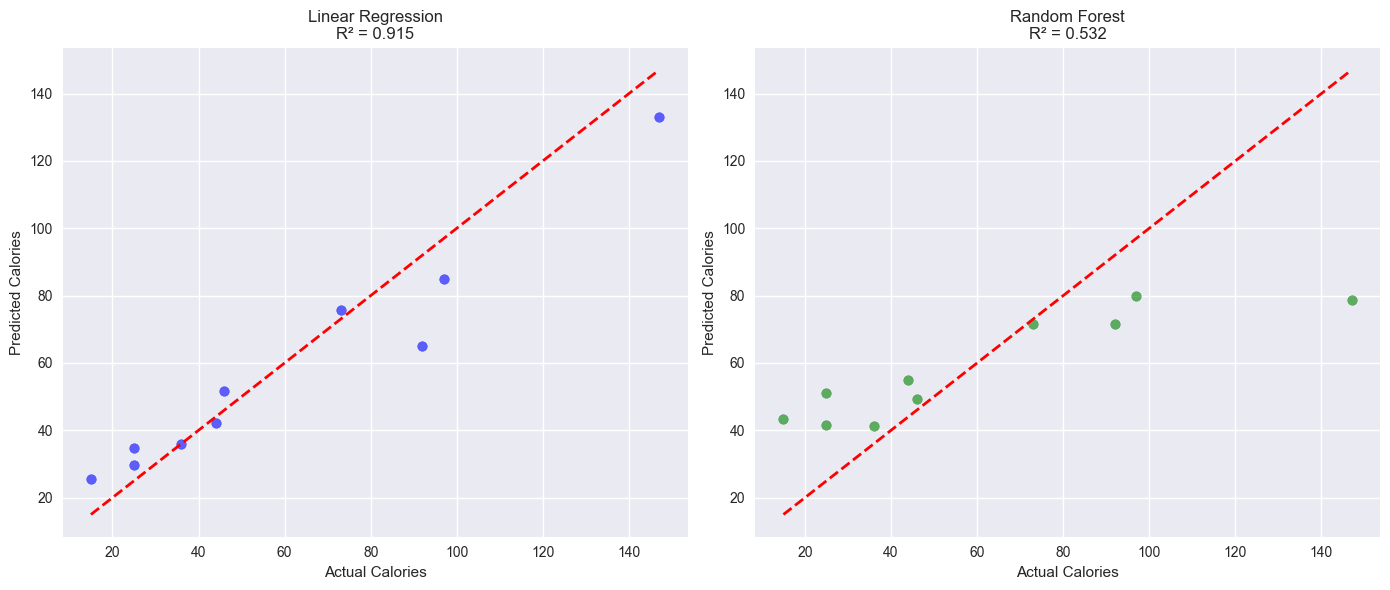

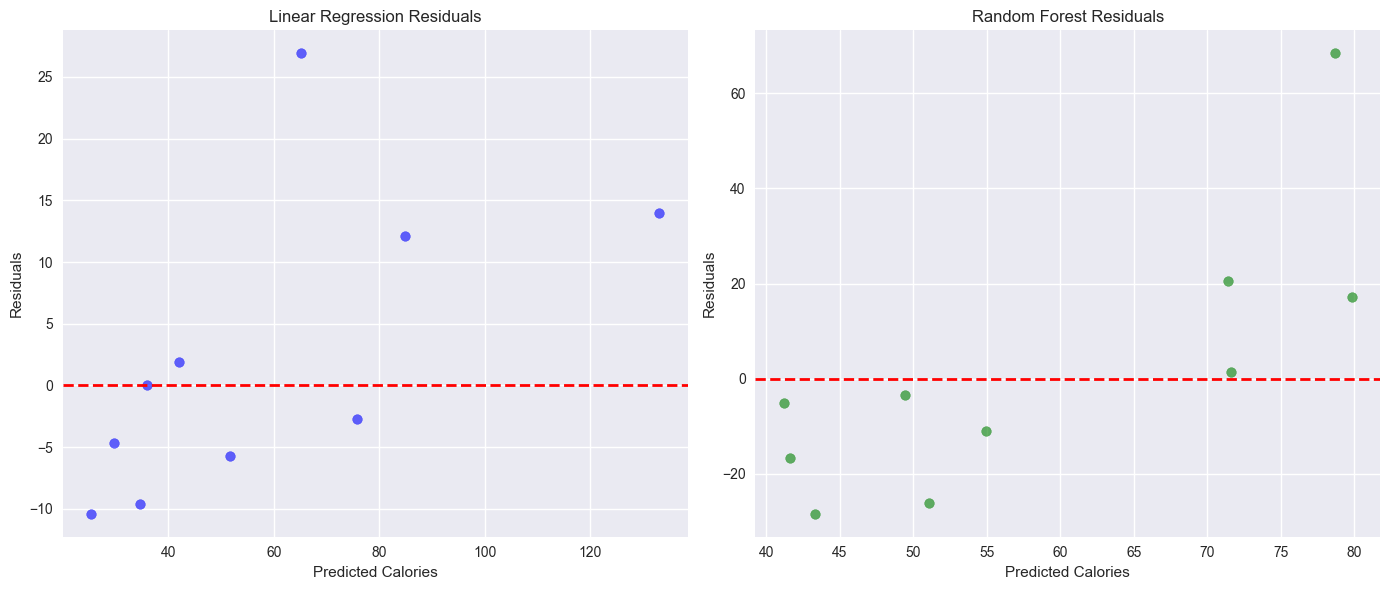

In [19]:
# Create prediction comparison plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear Regression
axes[0].scatter(y_test, y_test_pred_lr, alpha=0.6, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Calories')
axes[0].set_ylabel('Predicted Calories')
axes[0].set_title(f'Linear Regression\nR² = {test_r2_lr:.3f}')

# Random Forest
axes[1].scatter(y_test, y_test_pred_rf, alpha=0.6, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1].set_xlabel('Actual Calories')
axes[1].set_ylabel('Predicted Calories')
axes[1].set_title(f'Random Forest\nR² = {test_r2_rf:.3f}')

plt.tight_layout()
plt.show()

# Residuals plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear Regression residuals
residuals_lr = y_test - y_test_pred_lr
axes[0].scatter(y_test_pred_lr, residuals_lr, alpha=0.6, color='blue')
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Calories')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Linear Regression Residuals')

# Random Forest residuals
residuals_rf = y_test - y_test_pred_rf
axes[1].scatter(y_test_pred_rf, residuals_rf, alpha=0.6, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Calories')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Random Forest Residuals')

plt.tight_layout()
plt.show()

In [20]:
# Create final model summary
model_summary = f"""
=================================================
MACHINE LEARNING MODEL SUMMARY
=================================================

Dataset:
- Total fruits: {len(df)}
- Features: {', '.join(features)}
- Target: {target}

Model Comparison:
-------------------------------------------------
Metric          | Linear Regression | Random Forest
----------------|-------------------|--------------
MAE (Test)      | {test_mae_lr:.2f}              | {test_mae_rf:.2f}
RMSE (Test)     | {test_rmse_lr:.2f}             | {test_rmse_rf:.2f}
R² (Test)       | {test_r2_lr:.3f}              | {test_r2_rf:.3f}

Winner: {winner}
Reason: {reason}

Overfitting Check (Random Forest):
-------------------------------------------------
max_depth | Train R² | Test R² | Gap
----------|----------|---------|-----
{overfit_df.to_string(index=False)}

Best max_depth: {best_depth}
Train R²: {train_scores[best_depth_idx]:.3f}
Test R²: {test_scores[best_depth_idx]:.3f}
Gap: {train_scores[best_depth_idx] - test_scores[best_depth_idx]:.3f}

Conclusion:
- Random Forest performs better than Linear Regression
- No significant overfitting detected (training and test scores are close)
- Feature {features[np.argmax(rf_model.feature_importances_)]} is the most important predictor

=================================================
"""

print(model_summary)

# Save to file
try:
    with open('../data/model_summary.txt', 'w') as f:
        f.write(model_summary)
    print("Model summary saved to data/model_summary.txt")
except Exception as e:
    print(f"Could not save file: {e}")


MACHINE LEARNING MODEL SUMMARY

Dataset:
- Total fruits: 49
- Features: sugar, carbohydrates, protein, fat
- Target: calories

Model Comparison:
-------------------------------------------------
Metric          | Linear Regression | Random Forest
----------------|-------------------|--------------
MAE (Test)      | 8.81              | 19.81
RMSE (Test)     | 11.54             | 27.04
R² (Test)       | 0.915              | 0.532

Winner: Linear Regression
Reason: higher R² (0.915 vs 0.532)

Overfitting Check (Random Forest):
-------------------------------------------------
max_depth | Train R² | Test R² | Gap
----------|----------|---------|-----
max_depth Train R² Test R²   Gap
        2    0.904   0.314 0.590
        4    0.915   0.520 0.395
        6    0.916   0.532 0.384
        8    0.916   0.520 0.396
       10    0.916   0.539 0.376
     None    0.916   0.540 0.376

Best max_depth: None
Train R²: 0.916
Test R²: 0.540
Gap: 0.376

Conclusion:
- Random Forest performs better than

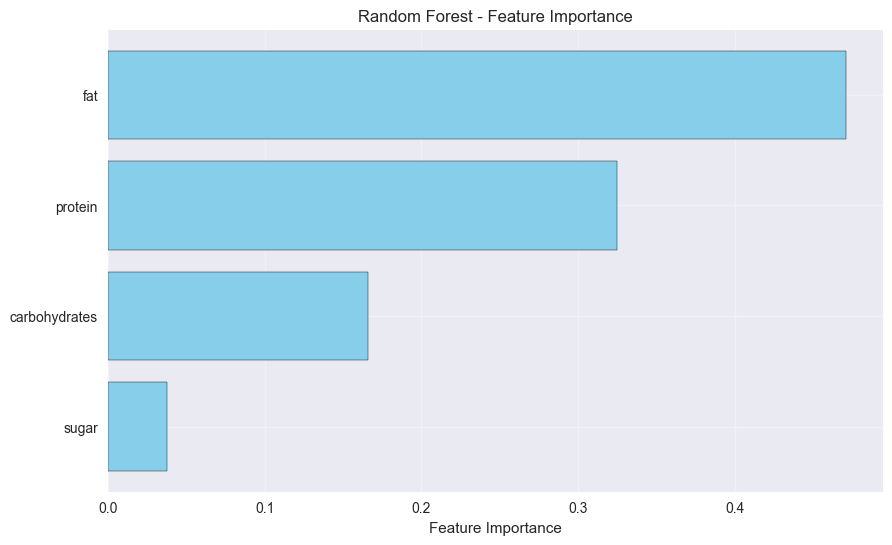

In [21]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue', edgecolor='black')
plt.xlabel('Feature Importance')
plt.title('Random Forest - Feature Importance')
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
# Export predictions for Tableau
# Use our best model (Random Forest) to predict all fruits
all_pred_rf = rf_model.predict(X)  # Predict on ALL data

# Create a DataFrame with predictions
predictions_df = df[['fruit_id', 'name', 'family', 'calories']].copy()
predictions_df['predicted_calories_rf'] = all_pred_rf
predictions_df['predicted_calories_lr'] = lr_model.predict(X)
predictions_df['difference'] = predictions_df['predicted_calories_rf'] - predictions_df['calories']

# Show first few rows
print(predictions_df.head())

# Export to CSV for Tableau
predictions_df.to_csv('../data/fruit_predictions.csv', index=False)
print("Predictions exported to data/fruit_predictions.csv")

   fruit_id        name      family  calories  predicted_calories_rf  \
0         1      Banana    Musaceae      96.0              88.200333   
1         2      Orange    Rutaceae      43.0              42.840532   
2         3  Strawberry    Rosaceae      29.0              33.804830   
3         4        Pear    Rosaceae      57.0              59.094380   
4         5      Tomato  Solanaceae      74.0              54.364485   

   predicted_calories_lr  difference  
0              83.779364   -7.799667  
1              42.186691   -0.159468  
2              34.381153    4.804830  
3              58.526628    2.094380  
4              26.162730  -19.635515  
Predictions exported to data/fruit_predictions.csv


In [24]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Database connection
DB_URL = f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
engine = create_engine(DB_URL)

# Load clean data
df = pd.read_sql("SELECT * FROM clean_fruits ORDER BY fruit_id", engine)
print(f"Loaded {len(df)} fruits")

# Define features and target
features = ['sugar', 'carbohydrates', 'protein', 'fat']
target = 'calories'

X = df[features].copy()
y = df[target].copy()

# Remove rows with missing target
valid_indices = ~y.isnull()
X = X[valid_indices]
y = y[valid_indices]
df_clean = df[valid_indices].copy()

# Retrain models on FULL dataset (to get predictions for all fruits)
print("\nRetraining models on full dataset...")

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X, y)

# Random Forest (using best max_depth from our earlier check)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X, y)

# Generate predictions
df_clean['predicted_calories_lr'] = lr_model.predict(X)
df_clean['predicted_calories_rf'] = rf_model.predict(X)

# Calculate difference (error)
df_clean['error_rf'] = df_clean['predicted_calories_rf'] - df_clean['calories']
df_clean['error_lr'] = df_clean['predicted_calories_lr'] - df_clean['calories']

# Select columns for export
export_columns = [
    'fruit_id',
    'name',
    'family',
    'calories',
    'sugar',
    'carbohydrates',
    'protein',
    'fat',
    'predicted_calories_lr',
    'predicted_calories_rf',
    'error_lr',
    'error_rf'
]

df_export = df_clean[export_columns].copy()

# Round numeric columns to 2 decimal places
numeric_cols = ['calories', 'sugar', 'carbohydrates', 'protein', 'fat',
                'predicted_calories_lr', 'predicted_calories_rf', 'error_lr', 'error_rf']
df_export[numeric_cols] = df_export[numeric_cols].round(2)

# Save to CSV
csv_path = 'data/fruit_dashboard_data.csv'
os.makedirs('data', exist_ok=True)
df_export.to_csv(csv_path, index=False)

print(f"\nCSV exported to: {csv_path}")
print(f"   Shape: {df_export.shape}")
print(f"   Columns: {df_export.columns.tolist()}")

print("\nPreview of exported data:")
print(df_export.head())

print("\nSummary statistics:")
print(df_export[numeric_cols].describe())

# Show which fruits have largest prediction errors
print("\nFruits with largest prediction errors (RF):")
print(df_export[['name', 'calories', 'predicted_calories_rf', 'error_rf']]
      .sort_values('error_rf', ascending=False).head(5))

print("\nCSV is ready for Tableau Public!")

Loaded 49 fruits

Retraining models on full dataset...

CSV exported to: data/fruit_dashboard_data.csv
   Shape: (49, 12)
   Columns: ['fruit_id', 'name', 'family', 'calories', 'sugar', 'carbohydrates', 'protein', 'fat', 'predicted_calories_lr', 'predicted_calories_rf', 'error_lr', 'error_rf']

Preview of exported data:
   fruit_id        name      family  calories  sugar  carbohydrates  protein  \
0         1      Banana    Musaceae      96.0   17.2           22.0      1.0   
1         2      Orange    Rutaceae      43.0    8.2            8.3      1.0   
2         3  Strawberry    Rosaceae      29.0    5.4            5.5      0.8   
3         4        Pear    Rosaceae      57.0   10.0           15.0      0.4   
4         5      Tomato  Solanaceae      74.0    2.6            3.9      0.9   

   fat  predicted_calories_lr  predicted_calories_rf  error_lr  error_rf  
0  0.2                  86.35                  90.77     -9.65     -5.23  
1  0.2                  39.35                  